In [1]:
##########################
# 0. pre-install
#

# !pip install keras_cv keras keras_hub
# !pip install tensorflow

In [2]:
##########################
# 1. lib
#

import json
import keras_hub
import keras_cv
import numpy as np
import keras
import requests

In [3]:
##########################
# 2. model
#

model = keras_cv.models.ImageClassifier.from_preset(
    "efficientnetv2_b0_imagenet_classifier"
)

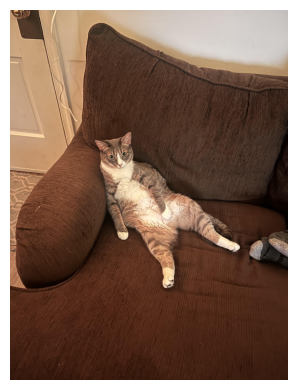

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
(1, 1000)


In [4]:
##########################
# 3. predict
#

url = "https://i.redd.it/twpfhcw58xgb1.jpg"

filepath = keras.utils.get_file(origin=url)
image = keras.utils.load_img(filepath)
image = np.array(image)
h, w, c = image.shape
image_batch = image.reshape((1, h, w, c))

keras_cv.visualization.plot_image_gallery(image_batch, rows=1, cols=1, value_range=(0, 255), show=True, scale=4)

preds = model.predict(image_batch)

print(preds.shape)

In [5]:
top_classes = (-preds[0]).argsort()

print(top_classes[:5])

[885 911 794 854 700]


In [6]:
label_name_url = 'https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/kerascv/imagenet_label_names.json'

label_names = requests.get(label_name_url).json()

print(label_names)

for idx in top_classes[:5]:
    print(label_names[idx])


['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead shark', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'American robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'American dipper', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'fire salamander', 'smooth newt', 'newt', 'spotted salamander', 'axolotl', 'American bullfrog', 'tree frog', 'tailed frog', 'loggerhead sea turtle', 'leatherback sea turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'green iguana', 'Carolina anole', 'desert grassland whiptail lizard', 'agama', 'frilled-necked lizard', 'alligator lizard', 'Gila monster', 'European green lizard', 'chameleon', 'Komodo dragon', 'Nile crocodile', 'American alligator', 'triceratops', 'worm snake', 'ring-necked snake', 'eastern hog-nosed snake', 'smooth green snake', 'kingsnake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'African rock p